# Prediksi Permintaan Produk Terlaris untuk Perencanaan Stok Barang

## Studi Kasus: Data Transaksi Retail UK

Project ini berfokus pada **Business Intelligence, Data Mining, dan Machine Learning** untuk memprediksi permintaan produk berdasarkan data transaksi historis.

### Tujuan utama
Memprediksi jumlah permintaan produk terlaris untuk beberapa minggu ke depan agar dapat digunakan sebagai dasar **perencanaan stok barang**.

### Masalah bisnis
Dalam bisnis retail, stok barang harus dipersiapkan dengan tepat. Jika stok terlalu sedikit, toko berisiko kehabisan barang. Jika stok terlalu banyak, barang akan menumpuk dan meningkatkan biaya penyimpanan.

### Output project
1. Analisis dataset transaksi retail.
2. Analisis tren penjualan berdasarkan waktu.
3. Pemilihan produk terlaris yang layak diprediksi.
4. Model prediksi permintaan produk berbasis time series.
5. Prediksi permintaan 8 minggu ke depan.
6. Rekomendasi stok dengan safety stock.
7. File export untuk Tableau/Power BI.

## Alur Penjelasan Saat Presentasi / Record

Urutan penjelasan yang disarankan:

1. Jelaskan dataset.
2. Jelaskan masalah bisnis.
3. Tampilkan hasil eksplorasi data.
4. Tampilkan produk yang dipilih untuk prediksi.
5. Tampilkan hasil prediksi dan grafik actual vs predicted.
6. Baru jelaskan preprocessing dan modeling.
7. Tutup dengan manfaat nyata dan kesimpulan.

In [ ]:
# ============================================================
# 1. IMPORT LIBRARY
# ============================================================

import os
import re
import zipfile
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    import joblib
except Exception:
    joblib = None

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

print('Library berhasil di-import')

Library berhasil di-import


In [ ]:
# ============================================================
# 2. PANGGIL DATASET DARI GOOGLE DRIVE
# ============================================================

# Jalankan di Google Colab.
# Pastikan file dataset sudah kamu upload ke Google Drive.
# Contoh nama file: dataset transaksi uk.zip

try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive berhasil di-mount')
except Exception as e:
    print('Bukan environment Google Colab atau Google Drive sudah aktif.')
    print('Info:', e)

# UBAH PATH INI SESUAI LOKASI FILE DI GOOGLE DRIVE KAMU
DATA_PATH = '/content/drive/MyDrive/dataset transaksi uk.zip'

# Folder output hasil analisis dan prediksi
OUTPUT_DIR = '/content/drive/MyDrive/output_forecasting_retail_uk'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Path dataset:', DATA_PATH)
print('Folder output:', OUTPUT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive berhasil di-mount
Path dataset: /content/drive/MyDrive/dataset transaksi uk.zip
Folder output: /content/drive/MyDrive/output_forecasting_retail_uk


In [ ]:
# ============================================================
# 3. FUNGSI LOAD DATA
# ============================================================

def load_retail_dataset(file_path):
    # Fungsi ini bisa membaca file ZIP berisi CSV atau file CSV langsung.
    if not os.path.exists(file_path):
        raise FileNotFoundError(
            f'File tidak ditemukan: {file_path}\\n'
            'Pastikan DATA_PATH sudah sesuai dengan lokasi file di Google Drive.'
        )

    if file_path.lower().endswith('.zip'):
        with zipfile.ZipFile(file_path, 'r') as z:
            csv_files = [name for name in z.namelist() if name.lower().endswith('.csv')]
            if len(csv_files) == 0:
                raise ValueError('File ZIP tidak berisi CSV.')

            csv_name = csv_files[0]
            print('CSV yang dibaca dari ZIP:', csv_name)

            with z.open(csv_name) as f:
                df = pd.read_csv(
                    f,
                    encoding='ISO-8859-1',
                    dtype={
                        'InvoiceNo': str,
                        'StockCode': str,
                        'Description': str,
                        'CustomerID': str,
                        'Country': str
                    }
                )
    else:
        df = pd.read_csv(
            file_path,
            encoding='ISO-8859-1',
            dtype={
                'InvoiceNo': str,
                'StockCode': str,
                'Description': str,
                'CustomerID': str,
                'Country': str
            }
        )

    return df

data_raw = load_retail_dataset(DATA_PATH)

print('Dataset berhasil dibaca')
print('Jumlah baris dan kolom:', data_raw.shape)
display(data_raw.head())

CSV yang dibaca dari ZIP: data.csv
Dataset berhasil dibaca
Jumlah baris dan kolom: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom


# Bagian A — Data Understanding

Pada bagian ini kita memahami struktur dataset sebelum masuk ke analisis dan model.

In [ ]:
# ============================================================
# 4. DATA UNDERSTANDING
# ============================================================

print('Informasi dataset:')
display(data_raw.info())

print('\nNama kolom:')
display(pd.DataFrame({'Kolom': data_raw.columns}))

print('\nContoh data:')
display(data_raw.head())

print('\nJumlah data duplikat:', data_raw.duplicated().sum())

print('\nJumlah missing value per kolom:')
display(data_raw.isna().sum().sort_values(ascending=False).to_frame('missing_value'))

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  object 
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 33.1+ MB


None


Nama kolom:


,Kolom
0,InvoiceNo
1,StockCode
2,Description
3,Quantity
4,InvoiceDate
5,UnitPrice
6,CustomerID
7,Country



Contoh data:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom



Jumlah data duplikat: 5268

Jumlah missing value per kolom:


,missing_value
CustomerID,135080
Description,1454
StockCode,0
InvoiceNo,0
Quantity,0
InvoiceDate,0
UnitPrice,0
Country,0


In [ ]:
# ============================================================
# 5. CEK RENTANG TANGGAL DAN NILAI DASAR
# ============================================================

data_check = data_raw.copy()
data_check['InvoiceDate'] = pd.to_datetime(data_check['InvoiceDate'], errors='coerce')

print('Rentang tanggal transaksi:')
print('Tanggal awal :', data_check['InvoiceDate'].min())
print('Tanggal akhir:', data_check['InvoiceDate'].max())

print('\nJumlah transaksi unik:', data_check['InvoiceNo'].nunique())
print('Jumlah produk unik:', data_check['StockCode'].nunique())
print('Jumlah pelanggan unik:', data_check['CustomerID'].nunique())
print('Jumlah negara:', data_check['Country'].nunique())

display(data_check[['Quantity', 'UnitPrice']].describe())

Rentang tanggal transaksi:
Tanggal awal : 2010-12-01 08:26:00
Tanggal akhir: 2011-12-09 12:50:00

Jumlah transaksi unik: 25900
Jumlah produk unik: 4070
Jumlah pelanggan unik: 4372
Jumlah negara: 38


,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


# Bagian B — Data Cleaning dan Preprocessing

Data hasil transaksi masih perlu dibersihkan karena terdapat transaksi retur/pembatalan, quantity negatif, harga tidak valid, dan deskripsi produk kosong.

In [ ]:
# ============================================================
# 6. DATA CLEANING
# ============================================================

df = data_raw.copy()

# Ubah tipe data tanggal
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# Hapus data tanggal kosong dan deskripsi kosong
df = df.dropna(subset=['InvoiceDate', 'Description'])

# Hapus duplikat
df = df.drop_duplicates()

# Pastikan InvoiceNo string
df['InvoiceNo'] = df['InvoiceNo'].astype(str)

# Deteksi transaksi pembatalan/retur
df['is_cancelled'] = df['InvoiceNo'].str.startswith('C', na=False)

print('Jumlah data awal:', len(data_raw))
print('Jumlah transaksi pembatalan/retur:', df['is_cancelled'].sum())

# Hanya gunakan transaksi valid untuk prediksi permintaan
df_clean = df[
    (df['is_cancelled'] == False) &
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0)
].copy()

# Buat kolom total penjualan
df_clean['TotalSales'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Bersihkan teks produk
df_clean['Description'] = df_clean['Description'].astype(str).str.strip().str.upper()
df_clean['Country'] = df_clean['Country'].fillna('Unknown')

print('Jumlah data setelah cleaning:', len(df_clean))
print('Data yang terhapus:', len(data_raw) - len(df_clean))

display(df_clean.head())

Jumlah data awal: 541909
Jumlah transaksi pembatalan/retur: 9251
Jumlah data setelah cleaning: 524878
Data yang terhapus: 17031


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancelled,TotalSales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34


In [ ]:
# ============================================================
# 7. FEATURE WAKTU UNTUK ANALISIS BI
# ============================================================

df_clean['Date'] = df_clean['InvoiceDate'].dt.date
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['MonthName'] = df_clean['InvoiceDate'].dt.month_name()
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M').astype(str)
df_clean['WeekStart'] = df_clean['InvoiceDate'].dt.to_period('W-SUN').apply(lambda r: r.start_time)
df_clean['DayName'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

display(df_clean[['InvoiceDate', 'YearMonth', 'WeekStart', 'DayName', 'Hour']].head())

,InvoiceDate,YearMonth,WeekStart,DayName,Hour
0,2010-12-01 08:26:00,2010-12,2010-11-29,Wednesday,8
1,2010-12-01 08:26:00,2010-12,2010-11-29,Wednesday,8
2,2010-12-01 08:26:00,2010-12,2010-11-29,Wednesday,8
3,2010-12-01 08:26:00,2010-12,2010-11-29,Wednesday,8
4,2010-12-01 08:26:00,2010-12,2010-11-29,Wednesday,8


# Bagian C — Exploratory Data Analysis

Bagian ini digunakan untuk mencari pola transaksi, tren penjualan, produk terlaris, dan negara dengan kontribusi terbesar.

In [ ]:
# ============================================================
# 8. KPI UTAMA DATASET
# ============================================================

total_revenue = df_clean['TotalSales'].sum()
total_quantity = df_clean['Quantity'].sum()
total_invoices = df_clean['InvoiceNo'].nunique()
total_products = df_clean['StockCode'].nunique()
total_customers = df_clean['CustomerID'].nunique()
total_countries = df_clean['Country'].nunique()

kpi = pd.DataFrame({
    'KPI': [
        'Total Revenue',
        'Total Quantity Terjual',
        'Total Invoice',
        'Total Produk Unik',
        'Total Customer Unik',
        'Total Negara'
    ],
    'Nilai': [
        total_revenue,
        total_quantity,
        total_invoices,
        total_products,
        total_customers,
        total_countries
    ]
})

display(kpi)

,KPI,Nilai
0,Total Revenue,1.064211e+07
1,Total Quantity Terjual,5.572420e+06
2,Total Invoice,1.996000e+04
3,Total Produk Unik,3.922000e+03
4,Total Customer Unik,4.338000e+03
5,Total Negara,3.800000e+01


,YearMonth,total_revenue,total_quantity,total_invoice
0,2010-12,821452.730,358019,1559
1,2011-01,689811.610,387099,1086
2,2011-02,522545.560,282934,1100
3,2011-03,716215.260,376599,1454
4,2011-04,536968.491,307953,1246
5,2011-05,769296.610,395001,1681
6,2011-06,760547.010,388511,1533
7,2011-07,718076.121,399693,1475
8,2011-08,757841.380,421020,1361
9,2011-09,1056435.192,569573,1837


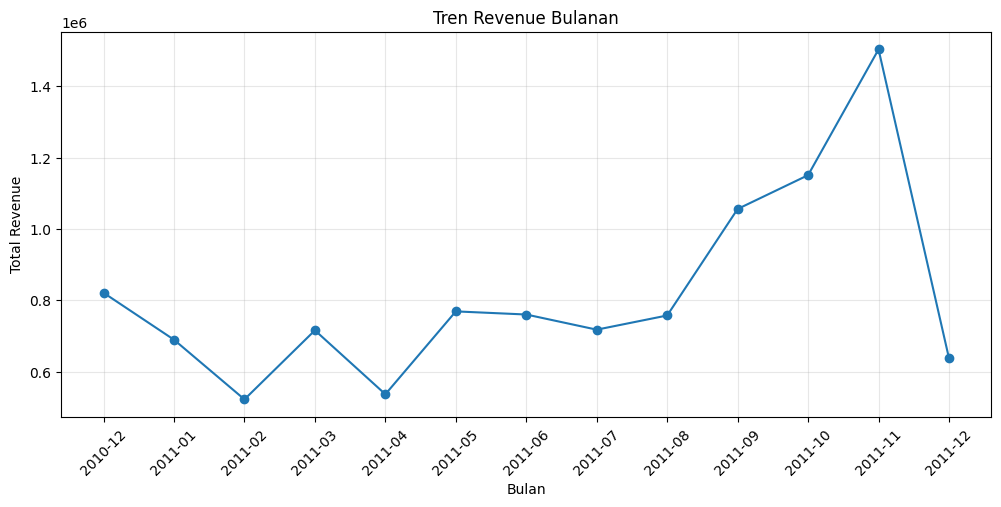

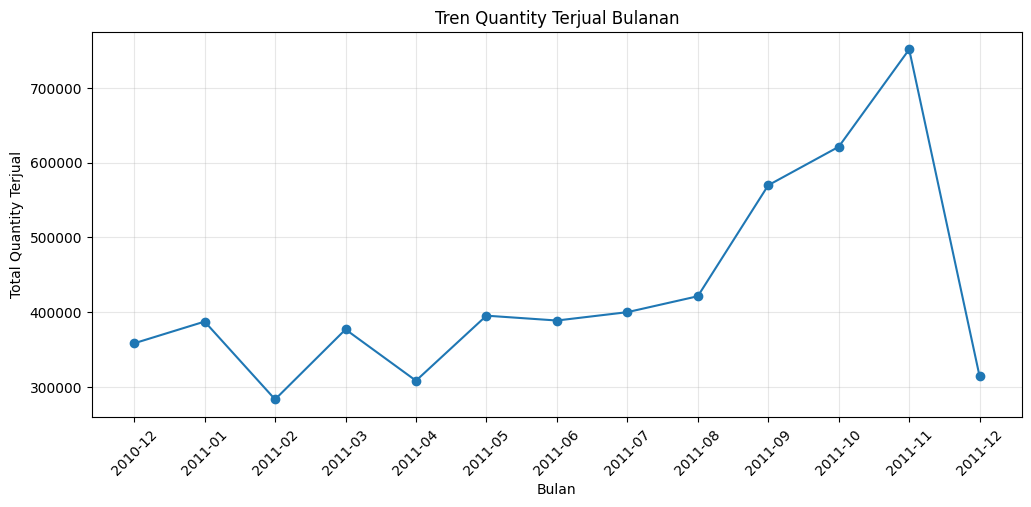

In [ ]:
# ============================================================
# 9. TREN REVENUE DAN QUANTITY PER BULAN
# ============================================================

monthly_sales = df_clean.groupby('YearMonth').agg(
    total_revenue=('TotalSales', 'sum'),
    total_quantity=('Quantity', 'sum'),
    total_invoice=('InvoiceNo', 'nunique')
).reset_index()

display(monthly_sales)

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['YearMonth'], monthly_sales['total_revenue'], marker='o')
plt.title('Tren Revenue Bulanan')
plt.xlabel('Bulan')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['YearMonth'], monthly_sales['total_quantity'], marker='o')
plt.title('Tren Quantity Terjual Bulanan')
plt.xlabel('Bulan')
plt.ylabel('Total Quantity Terjual')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

Top 10 produk berdasarkan jumlah terjual:


,StockCode,Description,total_quantity,total_revenue,invoice_count,active_weeks,avg_unit_price
2663,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1,1,2.080000
2119,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247,32,1.468480
3123,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951,13814.01,535,52,0.320728
3614,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81,2089,53,2.486197
3635,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37580,104284.24,2189,53,3.116159
1129,22197,POPCORN HOLDER,36749,34288.67,803,27,1.020836
448,21212,PACK OF 72 RETROSPOT CAKE CASES,36396,21246.45,1320,53,0.761206
3411,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,58927.62,1455,53,1.722575
2026,23084,RABBIT NIGHT LIGHT,30739,66870.03,994,31,2.386401
1405,22492,MINI PAINT SET VINTAGE,26633,16937.82,380,53,0.785026


Top 10 produk berdasarkan revenue:


,StockCode,Description,total_quantity,total_revenue,invoice_count,active_weeks,avg_unit_price
1340,22423,REGENCY CAKESTAND 3 TIER,13851,174156.54,1988,53,13.983936
2663,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1,1,2.080000
3635,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37580,104284.24,2189,53,3.116159
2872,47566,PARTY BUNTING,18283,99445.23,1685,53,5.797928
3614,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81,2089,53,2.486197
2119,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247,32,1.468480
2026,23084,RABBIT NIGHT LIGHT,30739,66870.03,994,31,2.386401
1022,22086,PAPER CHAIN KIT 50'S CHRISTMAS,19329,64875.59,1160,44,3.362331
3411,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,58927.62,1455,53,1.722575
3054,79321,CHILLI LIGHTS,10302,54096.36,661,53,6.795397


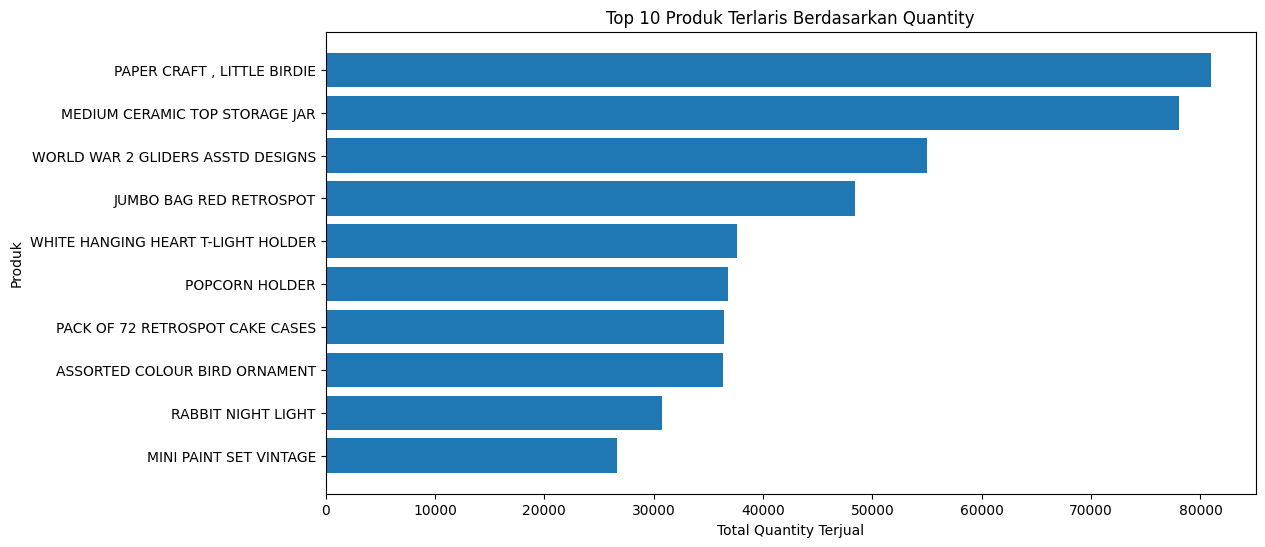

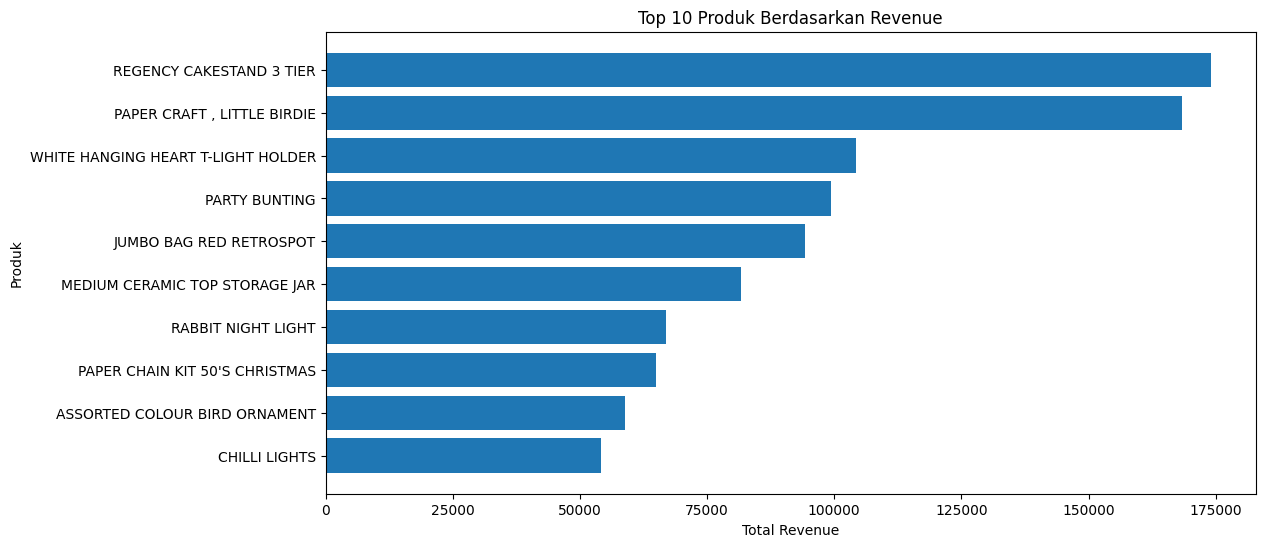

In [ ]:
# ============================================================
# 10. TOP 10 PRODUK TERLARIS DAN TOP REVENUE
# ============================================================

# Hapus produk non-barang agar analisis produk lebih masuk akal
non_product_keywords = [
    'POSTAGE', 'DOTCOM POSTAGE', 'MANUAL', 'AMAZON FEE',
    'BANK CHARGES', 'CARRIAGE', 'DISCOUNT', 'SAMPLES',
    'ADJUST BAD DEBT'
]

pattern = '|'.join(non_product_keywords)

df_product = df_clean[
    ~df_clean['Description'].str.contains(pattern, case=False, na=False)
].copy()

product_summary = df_product.groupby(['StockCode', 'Description']).agg(
    total_quantity=('Quantity', 'sum'),
    total_revenue=('TotalSales', 'sum'),
    invoice_count=('InvoiceNo', 'nunique'),
    active_weeks=('WeekStart', 'nunique'),
    avg_unit_price=('UnitPrice', 'mean')
).reset_index()

top_quantity = product_summary.sort_values('total_quantity', ascending=False).head(10)
top_revenue = product_summary.sort_values('total_revenue', ascending=False).head(10)

print('Top 10 produk berdasarkan jumlah terjual:')
display(top_quantity)

print('Top 10 produk berdasarkan revenue:')
display(top_revenue)

plt.figure(figsize=(12, 6))
plt.barh(top_quantity['Description'][::-1], top_quantity['total_quantity'][::-1])
plt.title('Top 10 Produk Terlaris Berdasarkan Quantity')
plt.xlabel('Total Quantity Terjual')
plt.ylabel('Produk')
plt.show()

plt.figure(figsize=(12, 6))
plt.barh(top_revenue['Description'][::-1], top_revenue['total_revenue'][::-1])
plt.title('Top 10 Produk Berdasarkan Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Produk')
plt.show()

,Country,total_revenue,total_quantity,total_invoice
36,United Kingdom,9001744.094,4646906,18019
24,Netherlands,285446.340,200361,94
10,EIRE,283140.520,147007,288
14,Germany,228678.400,119154,457
13,France,209625.370,112060,392
0,Australia,138453.810,83891,57
31,Spain,61558.560,27933,90
33,Switzerland,57067.600,30617,54
3,Belgium,41196.340,23237,98
32,Sweden,38367.830,36078,36


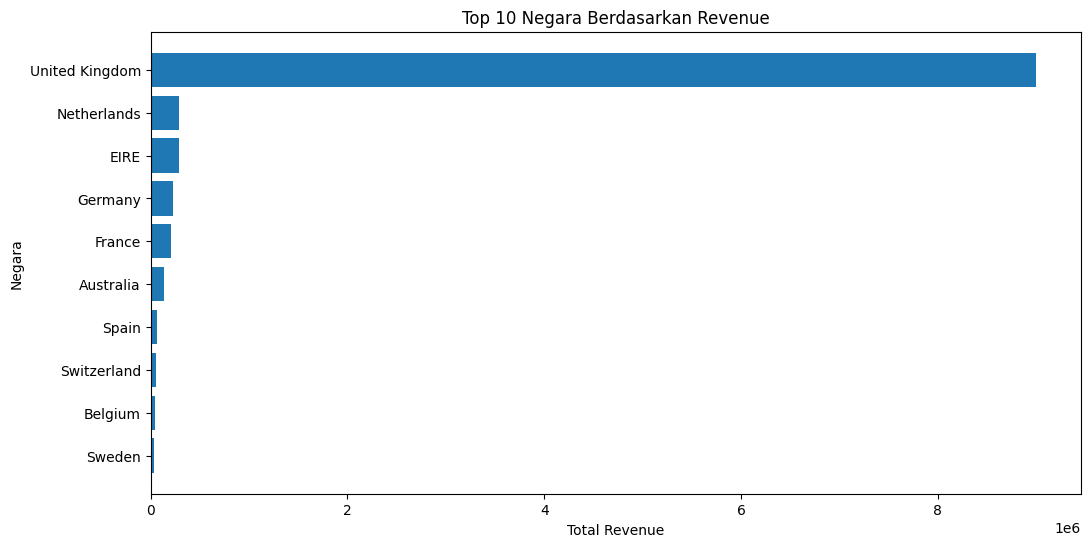

In [ ]:
# ============================================================
# 11. ANALISIS BERDASARKAN NEGARA
# ============================================================

country_summary = df_clean.groupby('Country').agg(
    total_revenue=('TotalSales', 'sum'),
    total_quantity=('Quantity', 'sum'),
    total_invoice=('InvoiceNo', 'nunique')
).reset_index().sort_values('total_revenue', ascending=False)

display(country_summary.head(15))

top_country = country_summary.head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_country['Country'][::-1], top_country['total_revenue'][::-1])
plt.title('Top 10 Negara Berdasarkan Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Negara')
plt.show()

# Bagian D — Pemilihan Produk untuk Forecasting

Agar model lebih fokus, project ini tidak memprediksi semua produk sekaligus.  
Produk yang diprediksi dipilih berdasarkan:

1. Jumlah terjual tinggi.
2. Jumlah invoice cukup banyak.
3. Aktif terjual di banyak minggu.
4. Bukan produk non-barang seperti postage/manual.

In [ ]:
# ============================================================
# 12. PEMILIHAN PRODUK UNTUK PREDIKSI
# ============================================================

# Mode manual atau auto
# manual = kamu tentukan sendiri StockCode produk
# auto   = sistem memilih produk yang paling layak berdasarkan data

PRODUCT_SELECTION_MODE = 'manual'

# Default produk yang cukup populer dan stabil pada dataset ini:
# 85099B = JUMBO BAG RED RETROSPOT
SELECTED_STOCKCODE = '85099B'

# Kriteria minimal produk layak diprediksi
MIN_ACTIVE_WEEKS = 30
MIN_INVOICE_COUNT = 100

eligible_products = product_summary[
    (product_summary['active_weeks'] >= MIN_ACTIVE_WEEKS) &
    (product_summary['invoice_count'] >= MIN_INVOICE_COUNT)
].copy()

# Skor sederhana untuk auto selection
eligible_products['score'] = (
    eligible_products['total_quantity'].rank(pct=True) * 0.45 +
    eligible_products['total_revenue'].rank(pct=True) * 0.30 +
    eligible_products['invoice_count'].rank(pct=True) * 0.15 +
    eligible_products['active_weeks'].rank(pct=True) * 0.10
)

if PRODUCT_SELECTION_MODE == 'manual':
    selected_product = product_summary[product_summary['StockCode'] == SELECTED_STOCKCODE].copy()

    if len(selected_product) == 0:
        print('StockCode manual tidak ditemukan. Sistem memilih produk otomatis.')
        selected_product = eligible_products.sort_values('score', ascending=False).head(1)
else:
    selected_product = eligible_products.sort_values('score', ascending=False).head(1)

selected_stockcode = selected_product.iloc[0]['StockCode']
selected_description = selected_product.iloc[0]['Description']

print('Produk yang dipilih untuk prediksi:')
print('StockCode   :', selected_stockcode)
print('Description :', selected_description)

display(selected_product)

print('\nProduk kandidat terbaik:')
display(eligible_products.sort_values('score', ascending=False).head(10))

Produk yang dipilih untuk prediksi:
StockCode   : 85099B
Description : JUMBO BAG RED RETROSPOT


,StockCode,Description,total_quantity,total_revenue,invoice_count,active_weeks,avg_unit_price
3614,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81,2089,53,2.486197



Produk kandidat terbaik:


,StockCode,Description,total_quantity,total_revenue,invoice_count,active_weeks,avg_unit_price,score
3635,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37580,104284.24,2189,53,3.116159,0.987781
3614,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81,2089,53,2.486197,0.987540
3411,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,58927.62,1455,53,1.722575,0.985008
2872,47566,PARTY BUNTING,18283,99445.23,1685,53,5.797928,0.981752
1307,22386,JUMBO BAG PINK POLKADOT,21448,42401.01,1218,53,2.598734,0.980426
179,20725,LUNCH BAG RED RETROSPOT,19232,35572.36,1564,53,2.131853,0.978859
1109,22178,VICTORIAN GLASS HANGING T-LIGHT,24275,33146.82,1037,53,1.644025,0.978376
1340,22423,REGENCY CAKESTAND 3 TIER,13851,174156.54,1988,53,13.983936,0.975844
1279,22355,CHARLOTTE BAG SUKI DESIGN,18124,29254.15,882,53,1.216607,0.970297
448,21212,PACK OF 72 RETROSPOT CAKE CASES,36396,21246.45,1320,53,0.761206,0.969695


In [ ]:
# ============================================================
# 13. FILTER DATA UNTUK PRODUK TERPILIH
# ============================================================

df_selected = df_product[df_product['StockCode'] == selected_stockcode].copy()

print('Jumlah baris transaksi produk terpilih:', len(df_selected))
print('Jumlah invoice produk terpilih:', df_selected['InvoiceNo'].nunique())
print('Rentang tanggal:', df_selected['InvoiceDate'].min(), 'sampai', df_selected['InvoiceDate'].max())

display(df_selected.head())

Jumlah baris transaksi produk terpilih: 2109
Jumlah invoice produk terpilih: 2089
Rentang tanggal: 2010-12-01 09:57:00 sampai 2011-12-09 10:26:00


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_cancelled,TotalSales,Date,Year,Month,MonthName,YearMonth,WeekStart,DayName,Hour
177,536386,85099B,JUMBO BAG RED RETROSPOT,100,2010-12-01 09:57:00,1.65,16029,United Kingdom,False,165.00,2010-12-01,2010,12,December,2010-12,2010-11-29,Wednesday,9
234,536390,85099B,JUMBO BAG RED RETROSPOT,100,2010-12-01 10:19:00,1.65,17511,United Kingdom,False,165.00,2010-12-01,2010,12,December,2010-12,2010-11-29,Wednesday,10
533,536409,85099B,JUMBO BAG RED RETROSPOT,2,2010-12-01 11:45:00,1.95,17908,United Kingdom,False,3.90,2010-12-01,2010,12,December,2010-12,2010-11-29,Wednesday,11
790,536464,85099B,JUMBO BAG RED RETROSPOT,1,2010-12-01 12:23:00,1.95,17968,United Kingdom,False,1.95,2010-12-01,2010,12,December,2010-12,2010-11-29,Wednesday,12
1069,536522,85099B,JUMBO BAG RED RETROSPOT,1,2010-12-01 12:49:00,1.95,15012,United Kingdom,False,1.95,2010-12-01,2010,12,December,2010-12,2010-11-29,Wednesday,12


# Bagian E — Pembentukan Data Time Series

Data transaksi diubah menjadi data mingguan agar model bisa melihat pola permintaan dari waktu ke waktu.

Target yang diprediksi adalah:

> total quantity terjual per minggu

Jumlah minggu pada data time series: 54


,WeekStart,quantity_sold,revenue,invoice_count,avg_unit_price
0,2010-11-29,692.0,1217.48,30.0,2.339032
1,2010-12-06,852.0,1576.32,42.0,2.674762
2,2010-12-13,427.0,863.67,34.0,2.539412
3,2010-12-20,180.0,361.68,13.0,3.143846
4,2010-12-27,0.0,0.00,0.0,3.143846


,WeekStart,quantity_sold,revenue,invoice_count,avg_unit_price
49,2011-11-07,2199.0,4226.77,70.0,2.318714
50,2011-11-14,1602.0,3102.01,60.0,2.299167
51,2011-11-21,753.0,1581.84,45.0,2.416739
52,2011-11-28,1050.0,2126.85,52.0,2.527736
53,2011-12-05,451.0,1001.33,37.0,2.611842


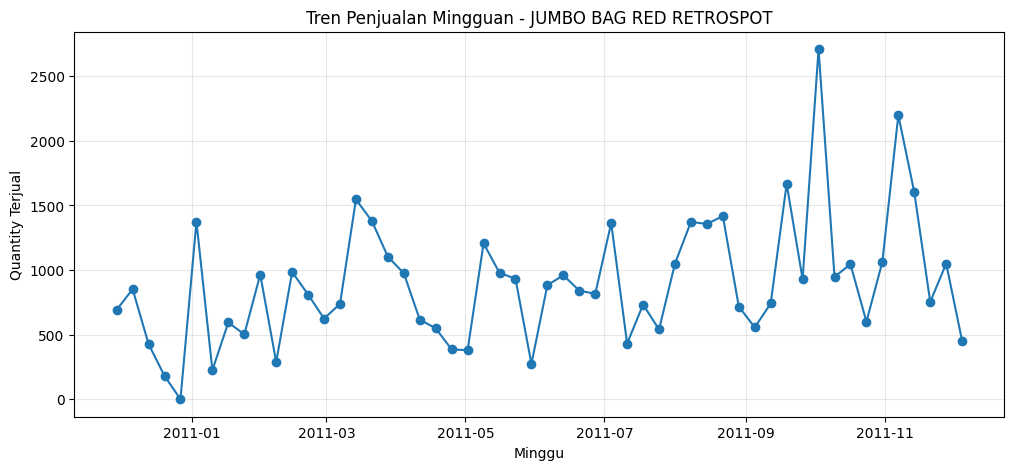

In [ ]:
# ============================================================
# 14. AGREGASI PENJUALAN MINGGUAN PRODUK TERPILIH
# ============================================================

weekly_sales = df_selected.groupby('WeekStart').agg(
    quantity_sold=('Quantity', 'sum'),
    revenue=('TotalSales', 'sum'),
    invoice_count=('InvoiceNo', 'nunique'),
    avg_unit_price=('UnitPrice', 'mean')
).reset_index().sort_values('WeekStart')

# Lengkapi minggu yang kosong supaya time series rapi
full_weeks = pd.DataFrame({
    'WeekStart': pd.date_range(
        start=weekly_sales['WeekStart'].min(),
        end=weekly_sales['WeekStart'].max(),
        freq='W-MON'
    )
})

weekly_sales = full_weeks.merge(weekly_sales, on='WeekStart', how='left')

weekly_sales['quantity_sold'] = weekly_sales['quantity_sold'].fillna(0)
weekly_sales['revenue'] = weekly_sales['revenue'].fillna(0)
weekly_sales['invoice_count'] = weekly_sales['invoice_count'].fillna(0)
weekly_sales['avg_unit_price'] = weekly_sales['avg_unit_price'].ffill().bfill()

print('Jumlah minggu pada data time series:', len(weekly_sales))
display(weekly_sales.head())
display(weekly_sales.tail())

plt.figure(figsize=(12, 5))
plt.plot(weekly_sales['WeekStart'], weekly_sales['quantity_sold'], marker='o')
plt.title(f'Tren Penjualan Mingguan - {selected_description}')
plt.xlabel('Minggu')
plt.ylabel('Quantity Terjual')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# ============================================================
# 15. FEATURE ENGINEERING TIME SERIES
# ============================================================

ts = weekly_sales.copy()

# Fitur kalender
ts['time_index'] = np.arange(len(ts))
ts['year'] = ts['WeekStart'].dt.year
ts['month'] = ts['WeekStart'].dt.month
ts['quarter'] = ts['WeekStart'].dt.quarter
ts['weekofyear'] = ts['WeekStart'].dt.isocalendar().week.astype(int)

# Lag features: penjualan minggu sebelumnya
for lag in [1, 2, 3, 4, 8]:
    ts[f'lag_{lag}'] = ts['quantity_sold'].shift(lag)

# Rolling features: rata-rata penjualan beberapa minggu sebelumnya
ts['rolling_mean_3'] = ts['quantity_sold'].shift(1).rolling(window=3).mean()
ts['rolling_mean_4'] = ts['quantity_sold'].shift(1).rolling(window=4).mean()
ts['rolling_mean_8'] = ts['quantity_sold'].shift(1).rolling(window=8).mean()
ts['rolling_std_4'] = ts['quantity_sold'].shift(1).rolling(window=4).std()

# Fitur revenue dan invoice minggu sebelumnya agar tidak bocor dari masa depan
ts['lag_revenue_1'] = ts['revenue'].shift(1)
ts['lag_invoice_1'] = ts['invoice_count'].shift(1)

# Hapus baris awal yang belum punya lag/rolling
model_data = ts.dropna().reset_index(drop=True)

print('Jumlah data setelah feature engineering:', model_data.shape)
display(model_data.head())

Jumlah data setelah feature engineering: (46, 21)


,WeekStart,quantity_sold,revenue,invoice_count,avg_unit_price,time_index,year,month,quarter,weekofyear,lag_1,lag_2,lag_3,lag_4,lag_8,rolling_mean_3,rolling_mean_4,rolling_mean_8,rolling_std_4,lag_revenue_1,lag_invoice_1
0,2011-01-24,502.0,904.70,26.0,2.574615,8,2011,1,1,4,594.0,225.0,1374.0,0.0,692.0,731.000000,548.25,543.000,602.501660,1145.12,31.0
1,2011-01-31,965.0,1786.35,43.0,2.465814,9,2011,1,1,5,502.0,594.0,225.0,1374.0,852.0,440.333333,673.75,519.250,492.471573,904.70,26.0
2,2011-02-07,288.0,568.66,21.0,2.662381,10,2011,2,1,6,965.0,502.0,594.0,225.0,427.0,687.000000,571.50,533.375,305.636494,1786.35,43.0
3,2011-02-14,985.0,1732.75,29.0,2.510000,11,2011,2,1,7,288.0,965.0,502.0,594.0,180.0,585.000000,587.25,516.000,282.582584,568.66,21.0
4,2011-02-21,810.0,1482.34,30.0,2.544000,12,2011,2,1,8,985.0,288.0,965.0,502.0,0.0,746.000000,685.00,616.625,346.168552,1732.75,29.0


# Bagian F — Modeling

Model yang digunakan:

1. Naive Forecast sebagai baseline.
2. Moving Average sebagai baseline.
3. Linear Regression.
4. Ridge Regression.
5. Random Forest Regressor.
6. Gradient Boosting Regressor.

Data dibagi secara kronologis, bukan random, karena ini data time series.

In [ ]:
# ============================================================
# 16. SPLIT DATA TRAINING DAN TESTING SECARA KRONOLOGIS
# ============================================================

feature_cols = [
    'time_index', 'year', 'month', 'quarter', 'weekofyear',
    'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_8',
    'rolling_mean_3', 'rolling_mean_4', 'rolling_mean_8', 'rolling_std_4',
    'lag_revenue_1', 'lag_invoice_1', 'avg_unit_price'
]

target_col = 'quantity_sold'

train_size = int(len(model_data) * 0.80)

train = model_data.iloc[:train_size].copy()
test = model_data.iloc[train_size:].copy()

X_train = train[feature_cols]
y_train = train[target_col]

X_test = test[feature_cols]
y_test = test[target_col]

print('Jumlah data training:', len(train))
print('Jumlah data testing :', len(test))

display(train[['WeekStart', 'quantity_sold']].head())
display(test[['WeekStart', 'quantity_sold']].head())

Jumlah data training: 36
Jumlah data testing : 10


,WeekStart,quantity_sold
0,2011-01-24,502.0
1,2011-01-31,965.0
2,2011-02-07,288.0
3,2011-02-14,985.0
4,2011-02-21,810.0


,WeekStart,quantity_sold
36,2011-10-03,2709.0
37,2011-10-10,947.0
38,2011-10-17,1045.0
39,2011-10-24,600.0
40,2011-10-31,1063.0


In [ ]:
# ============================================================
# 17. FUNGSI EVALUASI MODEL
# ============================================================

def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate_forecast(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, mape, r2

results = []
predictions = pd.DataFrame({
    'WeekStart': test['WeekStart'].values,
    'Actual': y_test.values
})

In [ ]:
# ============================================================
# 18. BASELINE MODEL: NAIVE DAN MOVING AVERAGE
# ============================================================

# Naive forecast: prediksi minggu ini = penjualan minggu sebelumnya
naive_pred = test['lag_1'].values

mae, rmse, mape, r2 = evaluate_forecast(y_test, naive_pred)
results.append({
    'Model': 'Naive Forecast',
    'MAE': mae,
    'RMSE': rmse,
    'MAPE (%)': mape,
    'R2': r2
})
predictions['Naive Forecast'] = naive_pred

# Moving average: rata-rata 4 minggu sebelumnya
moving_avg_pred = test['rolling_mean_4'].values

mae, rmse, mape, r2 = evaluate_forecast(y_test, moving_avg_pred)
results.append({
    'Model': 'Moving Average 4 Minggu',
    'MAE': mae,
    'RMSE': rmse,
    'MAPE (%)': mape,
    'R2': r2
})
predictions['Moving Average 4 Minggu'] = moving_avg_pred

display(pd.DataFrame(results))

,Model,MAE,RMSE,MAPE (%),R2
0,Naive Forecast,802.600,975.179881,74.164523,-1.036681
1,Moving Average 4 Minggu,746.575,867.011292,74.016589,-0.609915


In [ ]:
# ============================================================
# 19. MACHINE LEARNING MODEL
# ============================================================

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest Regressor': RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        max_depth=6,
        min_samples_leaf=2
    ),
    'Gradient Boosting Regressor': GradientBoostingRegressor(
        random_state=42,
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3
    )
}

trained_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    pred = np.maximum(model.predict(X_test), 0)

    mae, rmse, mape, r2 = evaluate_forecast(y_test, pred)

    results.append({
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape,
        'R2': r2
    })

    predictions[model_name] = pred
    trained_models[model_name] = model

metrics = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)

print('Perbandingan performa model:')
display(metrics)

best_model_name = metrics.iloc[0]['Model']
print('Model terbaik berdasarkan RMSE:', best_model_name)

Perbandingan performa model:


,Model,MAE,RMSE,MAPE (%),R2
0,Random Forest Regressor,477.125905,694.647760,36.211300,-0.033434
1,Gradient Boosting Regressor,517.951272,713.247427,41.214261,-0.089517
2,Ridge Regression,647.369728,840.503449,51.600138,-0.512978
3,Linear Regression,680.273918,866.602387,55.786039,-0.608397
4,Moving Average 4 Minggu,746.575000,867.011292,74.016589,-0.609915
5,Naive Forecast,802.600000,975.179881,74.164523,-1.036681


Model terbaik berdasarkan RMSE: Random Forest Regressor


,WeekStart,Actual_Quantity,Predicted_Quantity,Error,Absolute_Error
0,2011-10-03,2709.0,1143.0,1566.0,1566.0
1,2011-10-10,947.0,904.0,43.0,43.0
2,2011-10-17,1045.0,991.0,54.0,54.0
3,2011-10-24,600.0,929.0,-329.0,329.0
4,2011-10-31,1063.0,979.0,84.0,84.0
5,2011-11-07,2199.0,893.0,1306.0,1306.0
6,2011-11-14,1602.0,1068.0,534.0,534.0
7,2011-11-21,753.0,964.0,-211.0,211.0
8,2011-11-28,1050.0,799.0,251.0,251.0
9,2011-12-05,451.0,845.0,-394.0,394.0


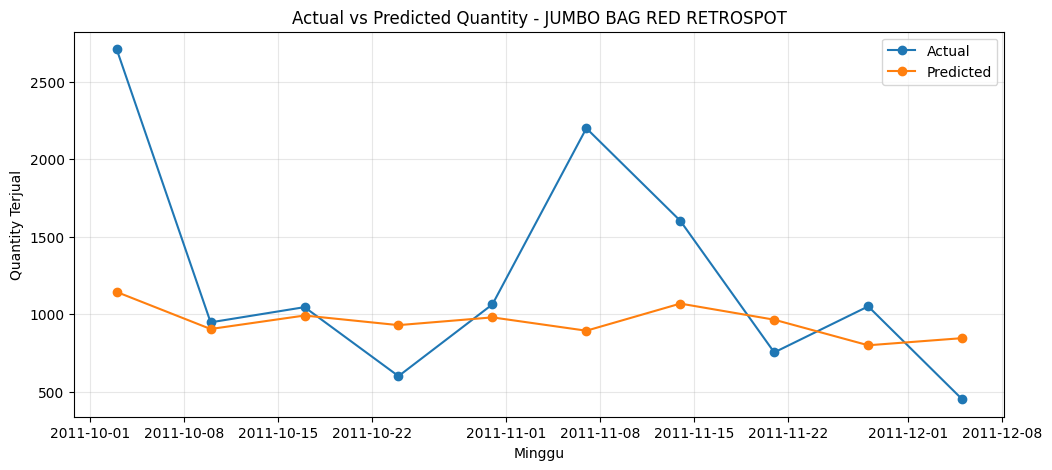

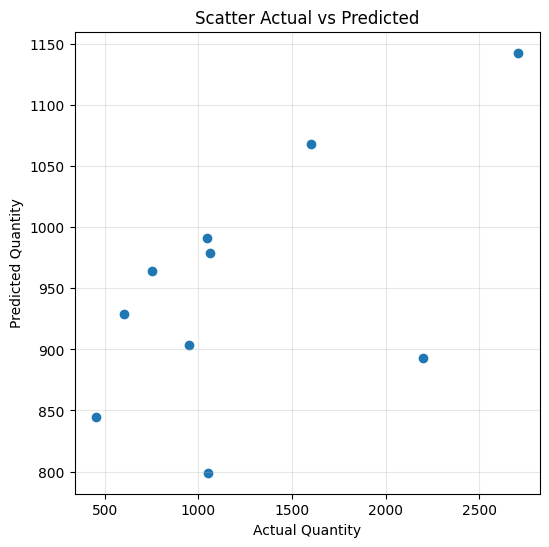

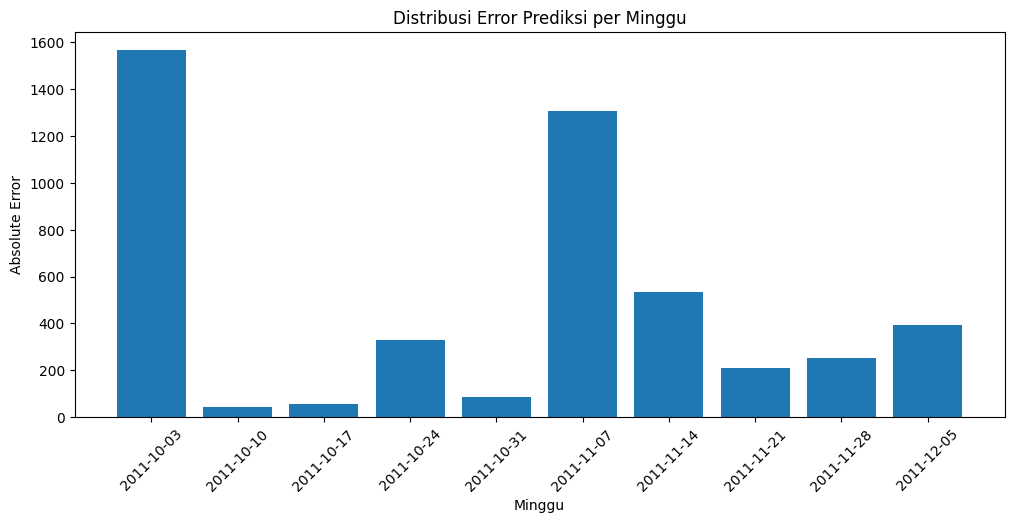

In [ ]:
# ============================================================
# 20. PILIH MODEL TERBAIK
# ============================================================

if best_model_name in trained_models:
    best_model = trained_models[best_model_name]
    best_pred = predictions[best_model_name].values
else:
    best_model = None
    best_pred = predictions[best_model_name].values

actual_vs_predicted = pd.DataFrame({
    'WeekStart': test['WeekStart'].values,
    'Actual_Quantity': y_test.values,
    'Predicted_Quantity': np.round(best_pred, 0),
    'Error': y_test.values - np.round(best_pred, 0),
    'Absolute_Error': np.abs(y_test.values - np.round(best_pred, 0))
})

display(actual_vs_predicted)

plt.figure(figsize=(12, 5))
plt.plot(actual_vs_predicted['WeekStart'], actual_vs_predicted['Actual_Quantity'], marker='o', label='Actual')
plt.plot(actual_vs_predicted['WeekStart'], actual_vs_predicted['Predicted_Quantity'], marker='o', label='Predicted')
plt.title(f'Actual vs Predicted Quantity - {selected_description}')
plt.xlabel('Minggu')
plt.ylabel('Quantity Terjual')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(actual_vs_predicted['Actual_Quantity'], actual_vs_predicted['Predicted_Quantity'])
plt.title('Scatter Actual vs Predicted')
plt.xlabel('Actual Quantity')
plt.ylabel('Predicted Quantity')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(actual_vs_predicted['WeekStart'].astype(str), actual_vs_predicted['Absolute_Error'])
plt.title('Distribusi Error Prediksi per Minggu')
plt.xlabel('Minggu')
plt.ylabel('Absolute Error')
plt.xticks(rotation=45)
plt.show()

,Feature,Importance
7,lag_3,0.236187
13,rolling_std_4,0.153843
16,avg_unit_price,0.093643
8,lag_4,0.065683
9,lag_8,0.064860
11,rolling_mean_4,0.058814
14,lag_revenue_1,0.051860
15,lag_invoice_1,0.049979
12,rolling_mean_8,0.038497
5,lag_1,0.037850


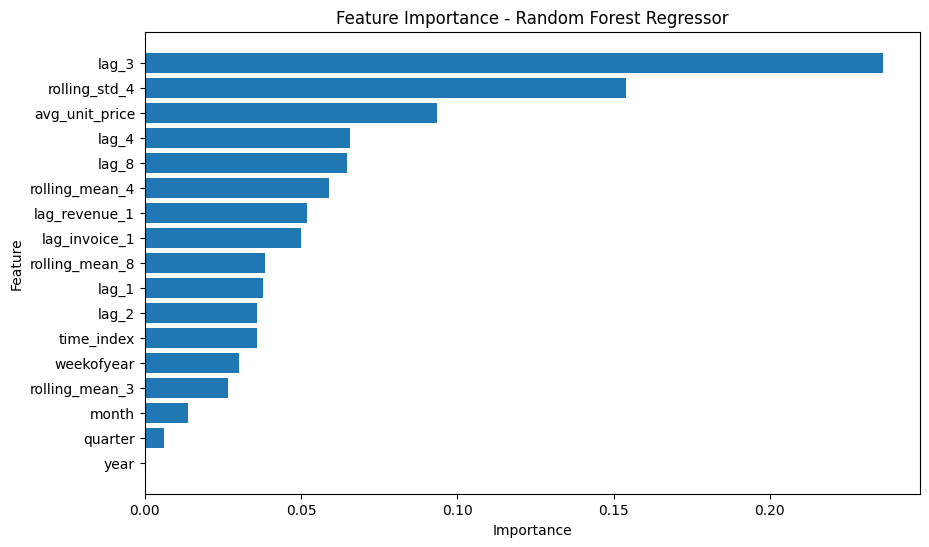

In [ ]:
# ============================================================
# 21. FEATURE IMPORTANCE UNTUK MODEL TREE-BASED
# ============================================================

if best_model_name in trained_models and hasattr(best_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    display(importance)

    plt.figure(figsize=(10, 6))
    plt.barh(importance['Feature'][::-1], importance['Importance'][::-1])
    plt.title(f'Feature Importance - {best_model_name}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()
else:
    print('Model terbaik tidak memiliki feature_importances_.')

# Bagian G — Forecast 8 Minggu ke Depan

Forecast dilakukan secara bertahap.  
Prediksi minggu pertama digunakan sebagai input lag untuk minggu berikutnya.

In [ ]:
# ============================================================
# 22. FUNGSI FORECAST BEBERAPA MINGGU KE DEPAN
# ============================================================

FORECAST_HORIZON = 8  # 8 minggu kira-kira mendekati 2 bulan

def forecast_future_weeks(ts_data, model, model_name, horizon=8):
    history = ts_data.copy().reset_index(drop=True)
    future_rows = []

    last_date = history['WeekStart'].max()
    avg_unit_price_last = history['avg_unit_price'].dropna().iloc[-1]

    for step in range(1, horizon + 1):
        future_date = last_date + pd.Timedelta(weeks=step)

        temp = history.copy()
        quantities = temp['quantity_sold'].values

        row = {
            'WeekStart': future_date,
            'time_index': len(temp),
            'year': future_date.year,
            'month': future_date.month,
            'quarter': ((future_date.month - 1) // 3) + 1,
            'weekofyear': int(future_date.isocalendar().week),
            'lag_1': quantities[-1],
            'lag_2': quantities[-2] if len(quantities) >= 2 else quantities[-1],
            'lag_3': quantities[-3] if len(quantities) >= 3 else quantities[-1],
            'lag_4': quantities[-4] if len(quantities) >= 4 else quantities[-1],
            'lag_8': quantities[-8] if len(quantities) >= 8 else quantities[-1],
            'rolling_mean_3': np.mean(quantities[-3:]) if len(quantities) >= 3 else np.mean(quantities),
            'rolling_mean_4': np.mean(quantities[-4:]) if len(quantities) >= 4 else np.mean(quantities),
            'rolling_mean_8': np.mean(quantities[-8:]) if len(quantities) >= 8 else np.mean(quantities),
            'rolling_std_4': np.std(quantities[-4:], ddof=1) if len(quantities) >= 4 else 0,
            'lag_revenue_1': temp['revenue'].iloc[-1],
            'lag_invoice_1': temp['invoice_count'].iloc[-1],
            'avg_unit_price': avg_unit_price_last
        }

        if model_name == 'Naive Forecast':
            pred_qty = row['lag_1']
        elif model_name == 'Moving Average 4 Minggu':
            pred_qty = row['rolling_mean_4']
        else:
            X_future = pd.DataFrame([row])[feature_cols]
            pred_qty = model.predict(X_future)[0]

        pred_qty = max(float(pred_qty), 0)
        pred_qty_rounded = int(round(pred_qty))

        future_rows.append({
            'WeekStart': future_date,
            'Predicted_Quantity': pred_qty_rounded
        })

        new_history_row = {
            'WeekStart': future_date,
            'quantity_sold': pred_qty_rounded,
            'revenue': pred_qty_rounded * avg_unit_price_last,
            'invoice_count': row['lag_invoice_1'],
            'avg_unit_price': avg_unit_price_last
        }
        history = pd.concat([history, pd.DataFrame([new_history_row])], ignore_index=True)

    return pd.DataFrame(future_rows)

future_forecast = forecast_future_weeks(
    weekly_sales,
    best_model,
    best_model_name,
    horizon=FORECAST_HORIZON
)

# Safety stock berbasis error model terbaik
best_model_mae = metrics.loc[metrics['Model'] == best_model_name, 'MAE'].iloc[0]
future_forecast['Safety_Stock'] = np.ceil(best_model_mae).astype(int)
future_forecast['Recommended_Stock'] = np.ceil(
    future_forecast['Predicted_Quantity'] + future_forecast['Safety_Stock']
).astype(int)

print('Prediksi permintaan 8 minggu ke depan:')
display(future_forecast)

Prediksi permintaan 8 minggu ke depan:


,WeekStart,Predicted_Quantity,Safety_Stock,Recommended_Stock
0,2011-12-12,1099,478,1577
1,2011-12-19,931,478,1409
2,2011-12-26,1023,478,1501
3,2012-01-02,794,478,1272
4,2012-01-09,990,478,1468
5,2012-01-16,934,478,1412
6,2012-01-23,1119,478,1597
7,2012-01-30,987,478,1465


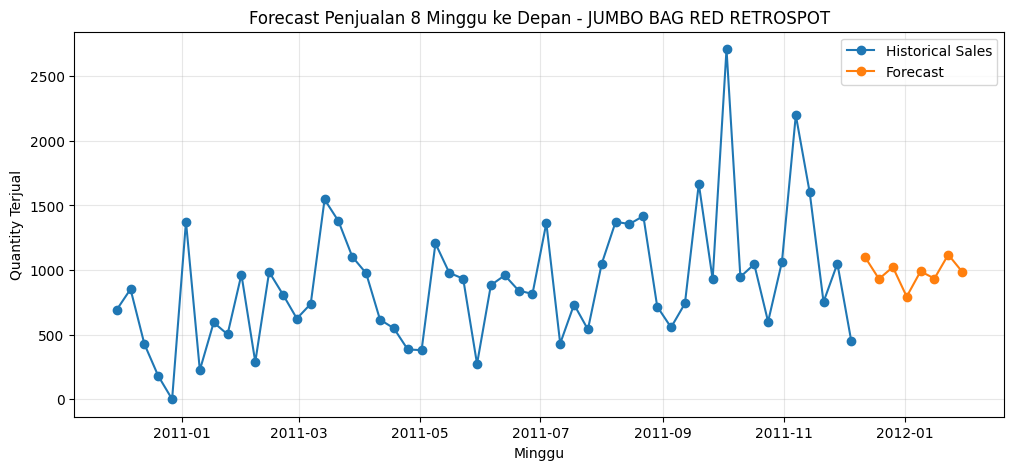

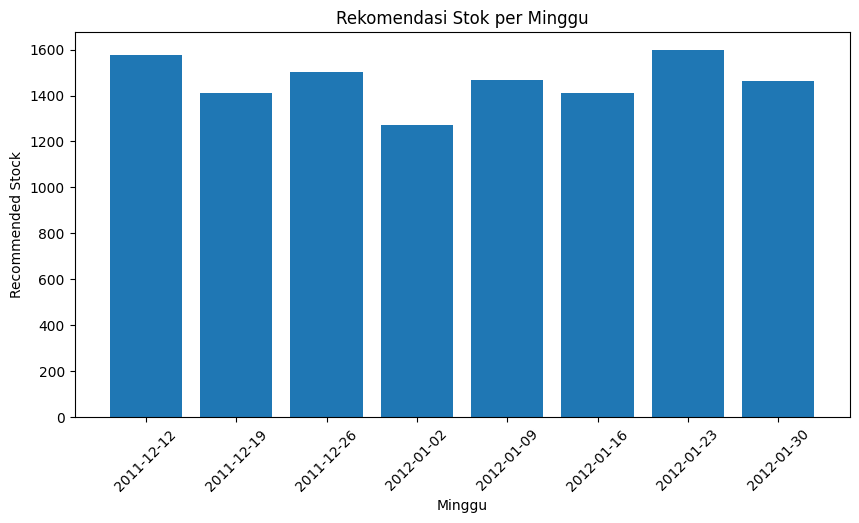

In [ ]:
# ============================================================
# 23. VISUALISASI FORECAST MASA DEPAN
# ============================================================

plt.figure(figsize=(12, 5))
plt.plot(weekly_sales['WeekStart'], weekly_sales['quantity_sold'], marker='o', label='Historical Sales')
plt.plot(future_forecast['WeekStart'], future_forecast['Predicted_Quantity'], marker='o', label='Forecast')
plt.title(f'Forecast Penjualan 8 Minggu ke Depan - {selected_description}')
plt.xlabel('Minggu')
plt.ylabel('Quantity Terjual')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(future_forecast['WeekStart'].astype(str), future_forecast['Recommended_Stock'])
plt.title('Rekomendasi Stok per Minggu')
plt.xlabel('Minggu')
plt.ylabel('Recommended Stock')
plt.xticks(rotation=45)
plt.show()

# Bagian H — Export Data untuk Tableau / Power BI

File hasil export dapat digunakan untuk membuat dashboard BI.

In [ ]:
# ============================================================
# 24. EXPORT FILE HASIL PROJECT
# ============================================================

# Tabel dashboard overview
monthly_sales.to_csv(os.path.join(OUTPUT_DIR, 'dashboard_monthly_sales.csv'), index=False)
country_summary.to_csv(os.path.join(OUTPUT_DIR, 'dashboard_country_summary.csv'), index=False)
top_quantity.to_csv(os.path.join(OUTPUT_DIR, 'dashboard_top_products_quantity.csv'), index=False)
top_revenue.to_csv(os.path.join(OUTPUT_DIR, 'dashboard_top_products_revenue.csv'), index=False)

# Tabel khusus forecasting
weekly_sales.to_csv(os.path.join(OUTPUT_DIR, 'weekly_sales_selected_product.csv'), index=False)
metrics.to_csv(os.path.join(OUTPUT_DIR, 'model_metrics.csv'), index=False)
actual_vs_predicted.to_csv(os.path.join(OUTPUT_DIR, 'actual_vs_predicted.csv'), index=False)
future_forecast.to_csv(os.path.join(OUTPUT_DIR, 'future_forecast_stock_recommendation.csv'), index=False)

# Export data bersih opsional
df_clean.to_csv(os.path.join(OUTPUT_DIR, 'cleaned_retail_data.csv'), index=False)

if joblib is not None and best_model is not None:
    joblib.dump(best_model, os.path.join(OUTPUT_DIR, 'best_forecasting_model.pkl'))

print('Semua file berhasil diexport ke:')
print(OUTPUT_DIR)

print('\nDaftar file output:')
for file in os.listdir(OUTPUT_DIR):
    print('-', file)

Semua file berhasil diexport ke:
/content/drive/MyDrive/output_forecasting_retail_uk

Daftar file output:
- dashboard_monthly_sales.csv
- dashboard_country_summary.csv
- dashboard_top_products_quantity.csv
- dashboard_top_products_revenue.csv
- weekly_sales_selected_product.csv
- model_metrics.csv
- actual_vs_predicted.csv
- future_forecast_stock_recommendation.csv
- cleaned_retail_data.csv
- best_forecasting_model.pkl
- multi_product_forecast.csv
- multi_product_model_metrics.csv
- multi_product_weekly_sales.csv
- multi_product_summary_2weeks.csv


# Bagian I — Kesimpulan Otomatis

In [ ]:
# ============================================================
# 25. RINGKASAN HASIL PROJECT
# ============================================================

print('RINGKASAN PROJECT')
print('=' * 60)
print('Judul Project:')
print('Prediksi Permintaan Produk Terlaris untuk Perencanaan Stok Barang')
print()
print('Dataset:')
print('- Data transaksi retail UK')
print('- Rentang tanggal:', df_clean['InvoiceDate'].min(), 'sampai', df_clean['InvoiceDate'].max())
print('- Jumlah transaksi valid:', df_clean['InvoiceNo'].nunique())
print('- Jumlah produk unik:', df_clean['StockCode'].nunique())
print()
print('Produk yang diprediksi:')
print('-', selected_description)
print('- StockCode:', selected_stockcode)
print()
print('Model terbaik:')
print('-', best_model_name)
print()
print('Performa model terbaik:')
display(metrics[metrics['Model'] == best_model_name])
print()
print('Prediksi 8 minggu ke depan dan rekomendasi stok:')
display(future_forecast)

RINGKASAN PROJECT
Judul Project:
Prediksi Permintaan Produk Terlaris untuk Perencanaan Stok Barang

Dataset:
- Data transaksi retail UK
- Rentang tanggal: 2010-12-01 08:26:00 sampai 2011-12-09 12:50:00
- Jumlah transaksi valid: 19960
- Jumlah produk unik: 3922

Produk yang diprediksi:
- JUMBO BAG RED RETROSPOT
- StockCode: 85099B

Model terbaik:
- Random Forest Regressor

Performa model terbaik:


,Model,MAE,RMSE,MAPE (%),R2
0,Random Forest Regressor,477.125905,694.64776,36.2113,-0.033434



Prediksi 8 minggu ke depan dan rekomendasi stok:


,WeekStart,Predicted_Quantity,Safety_Stock,Recommended_Stock
0,2011-12-12,1099,478,1577
1,2011-12-19,931,478,1409
2,2011-12-26,1023,478,1501
3,2012-01-02,794,478,1272
4,2012-01-09,990,478,1468
5,2012-01-16,934,478,1412
6,2012-01-23,1119,478,1597
7,2012-01-30,987,478,1465


In [ ]:

# ============================================================
# TAMBAHAN COLAB: MULTI-PRODUCT FORECASTING
# Copy semua kode ini ke cell paling bawah notebook Colab kamu,
# setelah notebook utama berhasil export hasil CSV.
# ============================================================

import os
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

OUTPUT_DIR = '/content/drive/MyDrive/output_forecasting_retail_uk'
os.makedirs(OUTPUT_DIR, exist_ok=True)

MAX_PRODUCTS_TO_FORECAST = 30
FORECAST_HORIZON = 8

def mape_safe(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate_model(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mape_safe(y_true, y_pred)
    try:
        r2 = r2_score(y_true, y_pred)
    except Exception:
        r2 = np.nan
    return mae, rmse, mape, r2

def make_weekly_sales_for_product(df_product, stockcode):
    df_selected = df_product[df_product['StockCode'] == stockcode].copy()
    weekly = df_selected.groupby('WeekStart').agg(
        quantity_sold=('Quantity', 'sum'),
        revenue=('TotalSales', 'sum'),
        invoice_count=('InvoiceNo', 'nunique'),
        avg_unit_price=('UnitPrice', 'mean')
    ).reset_index().sort_values('WeekStart')

    if weekly.empty:
        return weekly

    full_weeks = pd.DataFrame({
        'WeekStart': pd.date_range(
            start=weekly['WeekStart'].min(),
            end=weekly['WeekStart'].max(),
            freq='W-MON'
        )
    })

    weekly = full_weeks.merge(weekly, on='WeekStart', how='left')
    weekly['quantity_sold'] = weekly['quantity_sold'].fillna(0)
    weekly['revenue'] = weekly['revenue'].fillna(0)
    weekly['invoice_count'] = weekly['invoice_count'].fillna(0)
    weekly['avg_unit_price'] = weekly['avg_unit_price'].ffill().bfill()
    return weekly

def build_features(weekly):
    ts = weekly.copy()
    ts['time_index'] = np.arange(len(ts))
    ts['year'] = ts['WeekStart'].dt.year
    ts['month'] = ts['WeekStart'].dt.month
    ts['quarter'] = ts['WeekStart'].dt.quarter
    ts['weekofyear'] = ts['WeekStart'].dt.isocalendar().week.astype(int)

    for lag in [1, 2, 3, 4, 8]:
        ts[f'lag_{lag}'] = ts['quantity_sold'].shift(lag)

    ts['rolling_mean_3'] = ts['quantity_sold'].shift(1).rolling(3).mean()
    ts['rolling_mean_4'] = ts['quantity_sold'].shift(1).rolling(4).mean()
    ts['rolling_mean_8'] = ts['quantity_sold'].shift(1).rolling(8).mean()
    ts['rolling_std_4'] = ts['quantity_sold'].shift(1).rolling(4).std()
    ts['lag_revenue_1'] = ts['revenue'].shift(1)
    ts['lag_invoice_1'] = ts['invoice_count'].shift(1)
    return ts.dropna().reset_index(drop=True)

def train_product_model(model_data):
    feature_cols = [
        'time_index', 'year', 'month', 'quarter', 'weekofyear',
        'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_8',
        'rolling_mean_3', 'rolling_mean_4', 'rolling_mean_8', 'rolling_std_4',
        'lag_revenue_1', 'lag_invoice_1', 'avg_unit_price'
    ]

    train_size = int(len(model_data) * 0.80)
    train = model_data.iloc[:train_size].copy()
    test = model_data.iloc[train_size:].copy()

    if len(train) < 10 or len(test) < 3:
        return None

    X_train = train[feature_cols]
    y_train = train['quantity_sold']
    X_test = test[feature_cols]
    y_test = test['quantity_sold']

    models = {
        'Moving Average 4 Minggu': None,
        'Linear Regression': LinearRegression(),
        'Ridge Regression': Ridge(alpha=1.0),
        'Random Forest Regressor': RandomForestRegressor(
            n_estimators=120, random_state=42, max_depth=5, min_samples_leaf=2
        ),
        'Gradient Boosting Regressor': GradientBoostingRegressor(
            random_state=42, n_estimators=100, learning_rate=0.05, max_depth=3
        )
    }

    results = []
    trained = {}

    for name, model in models.items():
        if name == 'Moving Average 4 Minggu':
            pred = test['rolling_mean_4'].values
        else:
            model.fit(X_train, y_train)
            pred = np.maximum(model.predict(X_test), 0)
            trained[name] = model

        mae, rmse, mape, r2 = evaluate_model(y_test, pred)
        results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape, 'R2': r2})

    metrics = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
    best_name = metrics.iloc[0]['Model']
    best_model = None if best_name == 'Moving Average 4 Minggu' else trained[best_name]

    return {
        'feature_cols': feature_cols,
        'best_model_name': best_name,
        'best_model': best_model,
        'metrics': metrics,
        'mae': metrics.iloc[0]['MAE']
    }

def forecast_product_future(weekly, model, model_name, feature_cols, horizon=8):
    history = weekly.copy().reset_index(drop=True)
    rows = []
    last_date = history['WeekStart'].max()
    avg_price = history['avg_unit_price'].dropna().iloc[-1]

    for step in range(1, horizon + 1):
        future_date = last_date + pd.Timedelta(weeks=step)
        qty = history['quantity_sold'].values

        row = {
            'time_index': len(history),
            'year': future_date.year,
            'month': future_date.month,
            'quarter': ((future_date.month - 1) // 3) + 1,
            'weekofyear': int(future_date.isocalendar().week),
            'lag_1': qty[-1],
            'lag_2': qty[-2] if len(qty) >= 2 else qty[-1],
            'lag_3': qty[-3] if len(qty) >= 3 else qty[-1],
            'lag_4': qty[-4] if len(qty) >= 4 else qty[-1],
            'lag_8': qty[-8] if len(qty) >= 8 else qty[-1],
            'rolling_mean_3': np.mean(qty[-3:]) if len(qty) >= 3 else np.mean(qty),
            'rolling_mean_4': np.mean(qty[-4:]) if len(qty) >= 4 else np.mean(qty),
            'rolling_mean_8': np.mean(qty[-8:]) if len(qty) >= 8 else np.mean(qty),
            'rolling_std_4': np.std(qty[-4:], ddof=1) if len(qty) >= 4 else 0,
            'lag_revenue_1': history['revenue'].iloc[-1],
            'lag_invoice_1': history['invoice_count'].iloc[-1],
            'avg_unit_price': avg_price
        }

        if model_name == 'Moving Average 4 Minggu':
            pred = row['rolling_mean_4']
        else:
            pred = model.predict(pd.DataFrame([row])[feature_cols])[0]

        pred = max(float(pred), 0)
        pred_round = int(round(pred))

        rows.append({
            'Forecast_Week_Number': step,
            'Forecast_Date': future_date,
            'Predicted_Quantity': pred_round
        })

        new_row = {
            'WeekStart': future_date,
            'quantity_sold': pred_round,
            'revenue': pred_round * avg_price,
            'invoice_count': row['lag_invoice_1'],
            'avg_unit_price': avg_price
        }
        history = pd.concat([history, pd.DataFrame([new_row])], ignore_index=True)

    return pd.DataFrame(rows)

eligible = product_summary[
    (product_summary['active_weeks'] >= 25) &
    (product_summary['invoice_count'] >= 80)
].copy()

if eligible.empty:
    eligible = product_summary.copy()

eligible['score'] = (
    eligible['total_quantity'].rank(pct=True) * 0.45 +
    eligible['total_revenue'].rank(pct=True) * 0.30 +
    eligible['invoice_count'].rank(pct=True) * 0.15 +
    eligible['active_weeks'].rank(pct=True) * 0.10
)

candidate_products = eligible.sort_values('score', ascending=False).head(MAX_PRODUCTS_TO_FORECAST)

print('Jumlah produk yang akan diprediksi:', len(candidate_products))
display(candidate_products[['StockCode', 'Description', 'total_quantity', 'total_revenue', 'invoice_count', 'active_weeks', 'score']].head(10))

all_forecasts = []
all_metrics = []
all_weekly = []

for _, product in candidate_products.iterrows():
    stockcode = product['StockCode']
    desc = product['Description']
    print('Memproses:', stockcode, '-', desc)

    try:
        weekly = make_weekly_sales_for_product(df_product, stockcode)
        if weekly.empty or len(weekly) < 20:
            print('  skip: data mingguan sedikit')
            continue

        weekly['StockCode'] = stockcode
        weekly['Description'] = desc
        all_weekly.append(weekly)

        model_data = build_features(weekly)
        if len(model_data) < 15:
            print('  skip: data model sedikit')
            continue

        result = train_product_model(model_data)
        if result is None:
            print('  skip: training tidak cukup')
            continue

        forecast = forecast_product_future(
            weekly,
            result['best_model'],
            result['best_model_name'],
            result['feature_cols'],
            horizon=FORECAST_HORIZON
        )

        safety = int(np.ceil(result['mae']))
        forecast['StockCode'] = stockcode
        forecast['Description'] = desc
        forecast['Best_Model'] = result['best_model_name']
        forecast['Model_MAE'] = result['mae']
        forecast['Safety_Stock'] = safety
        forecast['Recommended_Stock_Weekly'] = forecast['Predicted_Quantity'] + safety
        forecast['Historical_Total_Quantity'] = product['total_quantity']
        forecast['Historical_Total_Revenue'] = product['total_revenue']
        forecast['Historical_Invoice_Count'] = product['invoice_count']
        forecast['Historical_Active_Weeks'] = product['active_weeks']

        all_forecasts.append(forecast)

        metrics = result['metrics'].copy()
        metrics['StockCode'] = stockcode
        metrics['Description'] = desc
        all_metrics.append(metrics)

    except Exception as e:
        print('  error:', e)

multi_product_forecast = pd.concat(all_forecasts, ignore_index=True)
multi_product_model_metrics = pd.concat(all_metrics, ignore_index=True)
multi_product_weekly_sales = pd.concat(all_weekly, ignore_index=True)

summary_2w = multi_product_forecast[
    multi_product_forecast['Forecast_Week_Number'] <= 2
].groupby(['StockCode', 'Description']).agg(
    Predicted_Quantity_2_Weeks=('Predicted_Quantity', 'sum'),
    Safety_Stock=('Safety_Stock', 'max'),
    Best_Model=('Best_Model', 'first'),
    Model_MAE=('Model_MAE', 'first'),
    Historical_Total_Quantity=('Historical_Total_Quantity', 'first'),
    Historical_Total_Revenue=('Historical_Total_Revenue', 'first'),
    Historical_Invoice_Count=('Historical_Invoice_Count', 'first'),
    Historical_Active_Weeks=('Historical_Active_Weeks', 'first')
).reset_index()

summary_2w['Recommended_Stock_2_Weeks'] = np.ceil(
    summary_2w['Predicted_Quantity_2_Weeks'] + summary_2w['Safety_Stock']
).astype(int)

q75 = summary_2w['Predicted_Quantity_2_Weeks'].quantile(0.75)
q40 = summary_2w['Predicted_Quantity_2_Weeks'].quantile(0.40)

summary_2w['Potensi_Laris'] = np.where(
    summary_2w['Predicted_Quantity_2_Weeks'] >= q75,
    'Sangat Laris',
    np.where(summary_2w['Predicted_Quantity_2_Weeks'] >= q40, 'Cukup Laris', 'Rendah')
)

summary_2w = summary_2w.sort_values('Predicted_Quantity_2_Weeks', ascending=False).reset_index(drop=True)
summary_2w['Rank_2_Weeks'] = np.arange(1, len(summary_2w) + 1)

multi_product_forecast.to_csv(os.path.join(OUTPUT_DIR, 'multi_product_forecast.csv'), index=False)
multi_product_model_metrics.to_csv(os.path.join(OUTPUT_DIR, 'multi_product_model_metrics.csv'), index=False)
multi_product_weekly_sales.to_csv(os.path.join(OUTPUT_DIR, 'multi_product_weekly_sales.csv'), index=False)
summary_2w.to_csv(os.path.join(OUTPUT_DIR, 'multi_product_summary_2weeks.csv'), index=False)

print('Selesai export multi-product forecasting ke:', OUTPUT_DIR)
display(summary_2w.head(10))


Jumlah produk yang akan diprediksi: 30


,StockCode,Description,total_quantity,total_revenue,invoice_count,active_weeks,score
3635,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37580,104284.24,2189,53,0.990123
3614,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81,2089,53,0.989929
3411,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,58927.62,1455,53,0.987589
2872,47566,PARTY BUNTING,18283,99445.23,1685,53,0.984958
1307,22386,JUMBO BAG PINK POLKADOT,21448,42401.01,1218,53,0.983886
179,20725,LUNCH BAG RED RETROSPOT,19232,35572.36,1564,53,0.982424
1109,22178,VICTORIAN GLASS HANGING T-LIGHT,24275,33146.82,1037,53,0.981839
1340,22423,REGENCY CAKESTAND 3 TIER,13851,174156.54,1988,53,0.980182
1279,22355,CHARLOTTE BAG SUKI DESIGN,18124,29254.15,882,53,0.974919
1882,22961,JAM MAKING SET PRINTED,16396,25637.78,1162,53,0.974042


Memproses: 85123A - WHITE HANGING HEART T-LIGHT HOLDER
Memproses: 85099B - JUMBO BAG RED RETROSPOT
Memproses: 84879 - ASSORTED COLOUR BIRD ORNAMENT
Memproses: 47566 - PARTY BUNTING
Memproses: 22386 - JUMBO BAG PINK POLKADOT
Memproses: 20725 - LUNCH BAG RED RETROSPOT
Memproses: 22178 - VICTORIAN GLASS HANGING T-LIGHT
Memproses: 22423 - REGENCY CAKESTAND 3 TIER
Memproses: 22355 - CHARLOTTE BAG SUKI DESIGN
Memproses: 22961 - JAM MAKING SET PRINTED
Memproses: 21931 - JUMBO STORAGE BAG SUKI
Memproses: 21212 - PACK OF 72 RETROSPOT CAKE CASES
Memproses: 22411 - JUMBO SHOPPER VINTAGE RED PAISLEY
Memproses: 85099C - JUMBO  BAG BAROQUE BLACK WHITE
Memproses: 21915 - RED  HARMONICA IN BOX
Memproses: 22629 - SPACEBOY LUNCH BOX
Memproses: 20724 - RED RETROSPOT CHARLOTTE BAG
Memproses: 21731 - RED TOADSTOOL LED NIGHT LIGHT
Memproses: 20727 - LUNCH BAG  BLACK SKULL.
Memproses: 85099F - JUMBO BAG STRAWBERRY
Memproses: 20728 - LUNCH BAG CARS BLUE
Memproses: 22699 - ROSES REGENCY TEACUP AND SAUCER
Mempr

,StockCode,Description,Predicted_Quantity_2_Weeks,Safety_Stock,Best_Model,Model_MAE,Historical_Total_Quantity,Historical_Total_Revenue,Historical_Invoice_Count,Historical_Active_Weeks,Recommended_Stock_2_Weeks,Potensi_Laris,Rank_2_Weeks
0,85099B,JUMBO BAG RED RETROSPOT,2264,512,Gradient Boosting Regressor,511.209395,48371,94159.81,2089,53,2776,Sangat Laris,1
1,22355,CHARLOTTE BAG SUKI DESIGN,1325,133,Moving Average 4 Minggu,132.400000,18124,29254.15,882,53,1458,Sangat Laris,2
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1216,322,Random Forest Regressor,321.854326,37580,104284.24,2189,53,1538,Sangat Laris,3
3,20724,RED RETROSPOT CHARLOTTE BAG,1195,107,Moving Average 4 Minggu,106.825000,17761,21773.39,1032,53,1302,Sangat Laris,4
4,22961,JAM MAKING SET PRINTED,1076,156,Moving Average 4 Minggu,155.650000,16396,25637.78,1162,53,1232,Sangat Laris,5
5,22178,VICTORIAN GLASS HANGING T-LIGHT,1005,316,Gradient Boosting Regressor,315.772734,24275,33146.82,1037,53,1321,Sangat Laris,6
6,79321,CHILLI LIGHTS,994,185,Moving Average 4 Minggu,184.350000,10302,54096.36,661,53,1179,Sangat Laris,7
7,85099C,JUMBO BAG BAROQUE BLACK WHITE,899,112,Ridge Regression,111.228272,13900,28047.74,933,53,1011,Sangat Laris,8
8,21212,PACK OF 72 RETROSPOT CAKE CASES,832,200,Moving Average 4 Minggu,199.750000,36396,21246.45,1320,53,1032,Cukup Laris,9
9,21731,RED TOADSTOOL LED NIGHT LIGHT,811,149,Linear Regression,148.701901,14001,23919.78,849,53,960,Cukup Laris,10


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip -o /content/custom_streamlit_prediksi_produk_laris_ui_premium.zip -d /content/streamlit_app
%cd /content/streamlit_app

Archive:  /content/custom_streamlit_prediksi_produk_laris_ui_premium.zip
  inflating: /content/streamlit_app/app.py  
  inflating: /content/streamlit_app/requirements.txt  
  inflating: /content/streamlit_app/README.md  
  inflating: /content/streamlit_app/colab_tambahan_multi_produk_forecast.py  
/content/streamlit_app


In [ ]:
!pkill -f streamlit
!pkill -f cloudflared

In [ ]:
!pip install -q streamlit pandas numpy plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 79.2 MB/s eta 0:00:00


In [ ]:
!wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared

!streamlit run app.py --server.address 0.0.0.0 --server.port 8501 & ./cloudflared tunnel --url http://localhost:8501

2026-06-11T15:47:56Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-06-11T15:47:56Z INF Requesting new quick Tunnel on trycloudflare.com...


2026-06-11T15:47:59Z INF +--------------------------------------------------------------------------------------------+
2026-06-11T15:47:59Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-06-11T15:47:59Z INF |  https://afternoon-fabrics-considered-attention.tryc

# Narasi Singkat untuk Presentasi

Berikut narasi yang bisa kamu pakai saat record:

> Pada project ini saya membuat prediksi permintaan produk terlaris untuk membantu perencanaan stok barang menggunakan data transaksi Retail UK. Dataset ini berisi data transaksi seperti nomor invoice, kode produk, nama produk, jumlah barang yang dibeli, tanggal transaksi, harga satuan, customer ID, dan negara pelanggan.  
>
> Kolom yang paling penting dalam project ini adalah InvoiceDate dan Quantity, karena dari dua kolom tersebut kita dapat melihat pola penjualan dari waktu ke waktu. Setelah dataset dipahami, data dibersihkan terlebih dahulu dengan menghapus transaksi retur, quantity negatif, harga tidak valid, dan data produk yang kosong.  
>
> Setelah preprocessing, saya melakukan exploratory data analysis untuk melihat total revenue, tren penjualan bulanan, produk terlaris, dan negara dengan kontribusi penjualan terbesar. Kemudian saya memilih satu produk yang layak diprediksi berdasarkan jumlah penjualan, jumlah invoice, dan keaktifan penjualan mingguan.  
>
> Data produk terpilih kemudian diubah menjadi time series mingguan. Model mempelajari pola penjualan menggunakan fitur waktu, lag penjualan minggu sebelumnya, dan rolling average. Beberapa model dibandingkan, seperti Linear Regression, Ridge Regression, Random Forest Regressor, dan Gradient Boosting Regressor.  
>
> Hasil model ditampilkan pada grafik actual vs predicted, yaitu perbandingan antara jumlah penjualan aktual dan hasil prediksi. Setelah model terbaik dipilih, sistem menghasilkan prediksi penjualan 8 minggu ke depan dan rekomendasi stok dengan tambahan safety stock.  
>
> Kesimpulannya, project ini dapat membantu bisnis retail memperkirakan kebutuhan stok barang berdasarkan pola penjualan historis, sehingga dapat mengurangi risiko kehabisan stok maupun kelebihan stok.

# Catatan Pengembangan

Project ini masih dapat dikembangkan dengan:

1. Menambahkan data beberapa tahun agar pola musiman lebih kuat.
2. Membuat prediksi untuk beberapa produk sekaligus.
3. Menambahkan segmentasi pelanggan menggunakan RFM Analysis.
4. Membuat dashboard interaktif di Tableau atau Power BI.
5. Menggunakan model time series lain seperti ARIMA, Prophet, atau LSTM.